# Importing Libraries

In [1]:
# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import class to standardize features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler

# Import the k-Nearest Neighbors classifier algorithm
from sklearn.neighbors import KNeighborsClassifier

# Import tools for evaluating classification models: classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix

# Import seaborn for enhanced data visualization (especially for plotting the confusion matrix)
import seaborn as sns

# Import matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Import pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations and working with arrays
import numpy as np

# Import function to evaluate a model using cross-validation
from sklearn.model_selection import cross_val_score
   

# Importing the Dataset

In [2]:
# Load the Excel file into a pandas DataFrame
df = pd.read_excel("balanced_cleaned_pollution_dataset.xlsx")

# Display the first 5 rows of the DataFrame to get a quick look at the data
display(df.head())


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.9,81.0,3.9,14.9,25.2,10.9,1.24,6.4,366,Moderate
1,24.2,63.9,6.6,9.1,24.1,2.7,0.93,12.8,369,Good
2,25.9,62.8,2.0,8.4,12.1,6.5,1.17,10.4,487,Good
3,25.7,78.9,47.3,61.1,32.0,8.7,1.23,7.4,530,Moderate
4,32.3,53.7,39.7,43.7,27.2,12.5,1.59,5.0,363,Moderate


# Train Test Split

In [3]:
# Separate the features (X) by dropping the target column 'Air Quality'
X = df.drop(columns='Air Quality')

# Store the target variable (y), which is the 'Air Quality' column
y = df['Air Quality']

# Import LabelEncoder to convert categorical target labels into numerical values
from sklearn.preprocessing import LabelEncoder

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target labels into integer-encoded form
y_encoded = label_encoder.fit_transform(y)

# Split the dataset into training and testing sets
# test_size=0.3 means 30% for testing, 70% for training
# random_state=42 ensures reproducibility
# stratify=y_encoded ensures that the class distribution is maintained in both training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)


# Feature Scaling

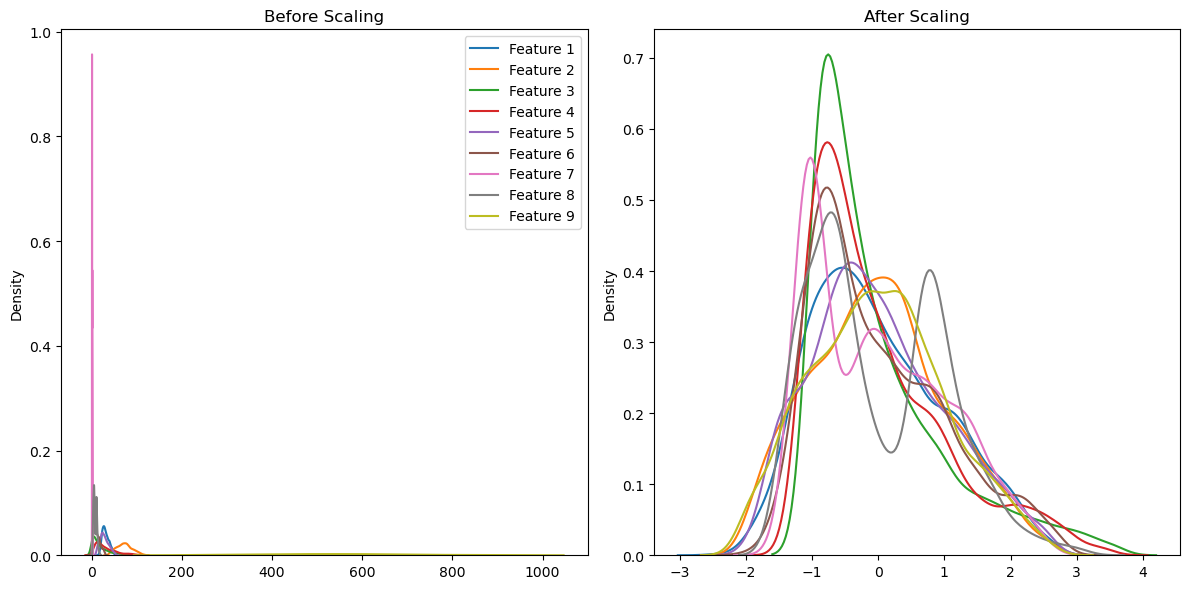

In [4]:
# Create an instance of StandardScaler to standardize features
scaler = StandardScaler()

# Scale the entire dataset (X)
X_scaled = scaler.fit_transform(X)

# Fit the scaler on the training set and transform it (learns mean and std from X_train)
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test set using the same scaler (uses mean and std from training set)
X_test_scaled = scaler.transform(X_test)

# Convert X_train to a NumPy array for plotting purposes
X_train_np = X_train.values 

# Create a figure with two subplots side by side (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Plot the distribution of each feature before and after scaling
for i in range(X_train_np.shape[1]):
    # Plot KDE (Kernel Density Estimate) for each original feature
    sns.kdeplot(X_train_np[:, i], ax=axes[0], label=f'Feature {i+1}')
    # Plot KDE for each scaled feature
    sns.kdeplot(X_train_scaled[:, i], ax=axes[1])

# Set titles for the subplots
axes[0].set_title('Before Scaling')
axes[1].set_title('After Scaling')

# Show legend for original features
axes[0].legend()

# Adjust subplot layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()


# Training and Predictions

In [5]:
# Create a K-Nearest Neighbors classifier with k=1 (using the closest neighbor for prediction)
knn = KNeighborsClassifier(n_neighbors=1)

# Train (fit) the KNN model using the scaled training data and corresponding labels
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=1)

In [6]:
# Use the trained KNN model to make predictions on the scaled test data
y_pred = knn.predict(X_test_scaled)

# Evaluating the Algorithm

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       498
           1       0.95      0.94      0.95       284
           2       0.92      0.99      0.96       356
           3       0.93      0.86      0.89       284

    accuracy                           0.96      1422
   macro avg       0.95      0.95      0.95      1422
weighted avg       0.96      0.96      0.96      1422



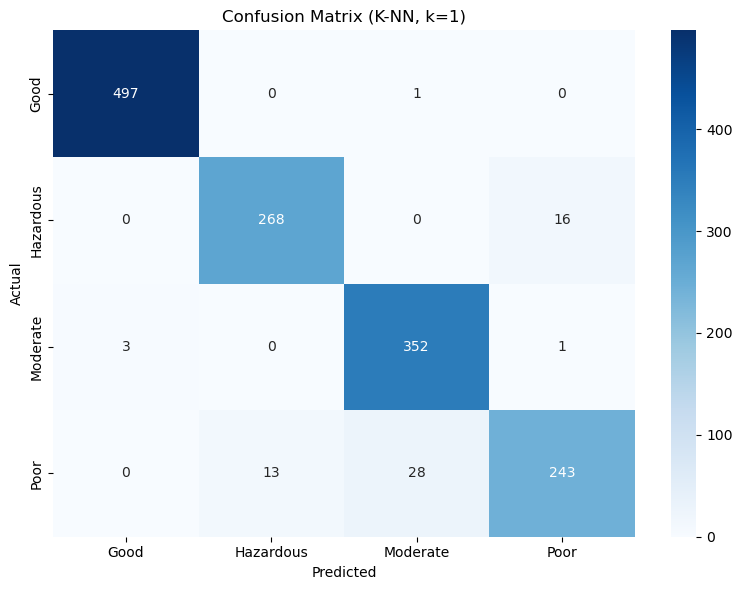

In [7]:
# Print a detailed classification report including precision, recall, f1-score, and support for each class
print(classification_report(y_test, y_pred))

# Compute the confusion matrix to evaluate the accuracy of classification
cm = confusion_matrix(y_test, y_pred)

# Get the original class names (before label encoding) for labeling the axes
class_names = label_encoder.classes_

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

# Label the axes and add a title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (K-NN, k=1)")

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the confusion matrix plot
plt.show()


In [8]:
# Perform 5-fold cross-validation using the KNN model on the entire scaled dataset
# This helps evaluate the model's generalizability
scores = cross_val_score(knn, X_scaled, y_encoded, cv=5)

# Print the accuracy score for each of the 5 folds
print("Cross-validation scores:", scores)

# Print the average accuracy across all folds
print("Mean accuracy:", scores.mean())


Cross-validation scores: [0.9556962  0.95780591 0.95886076 0.96308017 0.95991561]
Mean accuracy: 0.959071729957806


# Comparing Error Rate with the K Value

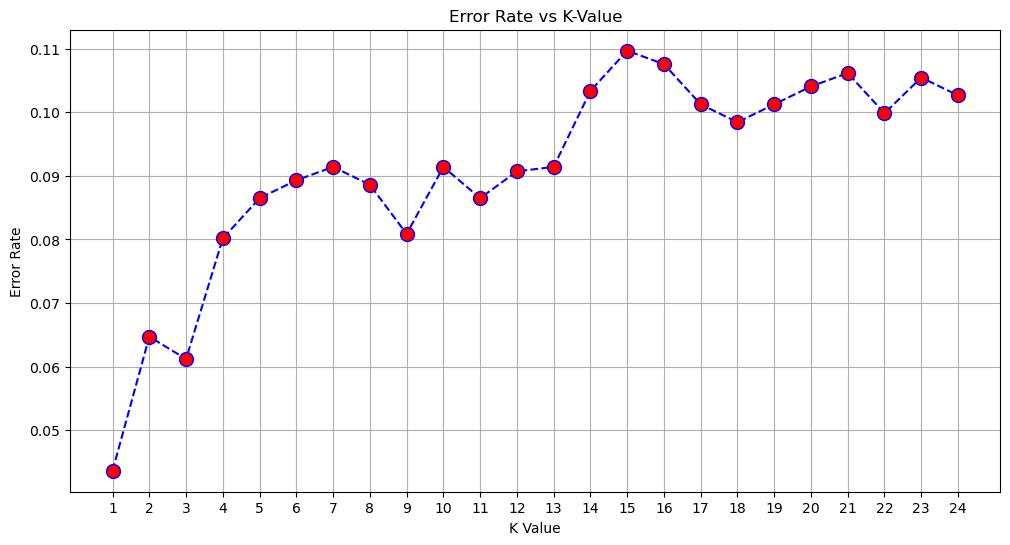

The Best values of k with the minimum error are/is : [1] and a minimum error = 4.36%


In [9]:
from sklearn.neighbors import KNeighborsClassifier

 
k_points= range(1, 25) # Initialize the values of k to find the best k .
min_error=10000 # Initialize a high value of error to help in finding the best k with  minimum error.

error = [] # a list to store the error rates.
best_k=[] # a list to store the best valuse of k ,

# Calculating error rates for K values between 1 and 25
for k in k_points :
    k_nn = KNeighborsClassifier(n_neighbors=k)
    k_nn.fit(X_train_scaled, y_train)  # training the model on the training set 
    pred_y = k_nn.predict(X_test_scaled) # predicting the class of the test set.
    
    error.append(np.mean(pred_y != y_test)) # calculating the mean error .
    
    new_error=np.mean(pred_y != y_test) # Creating a variable to use in the condition .
    
    # condition  for finding the best value of k 
    if new_error< min_error : 
      
        min_error=new_error
        
        best_k=[k]
        
    elif new_error == min_error: # it may there some k values have same error rate .
        best_k.append(k)  
                
            
    
# plotting the error rate vs k-value.    
plt.figure(figsize=(12, 6))
plt.plot(k_points, error, color='blue', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)

plt.title('Error Rate vs K-Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')  

plt.xticks(k_points)
plt.grid()
plt.show()


print(f"The Best values of k with the minimum error are/is : {best_k} and a minimum error = {min(error)*100:.2f}%")

# Sample usage of Nearest Neighbors classification. It will plot the decision boundaries for each class.

Training set shape: (3792, 2)
Test set shape: (948, 2)


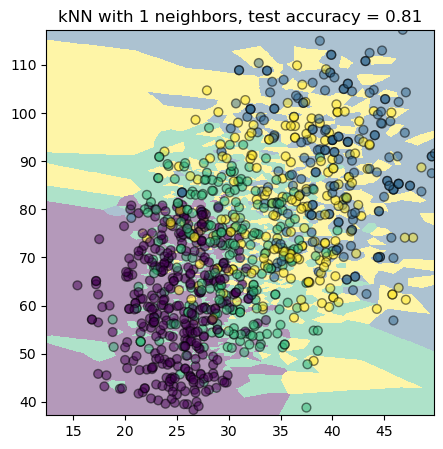

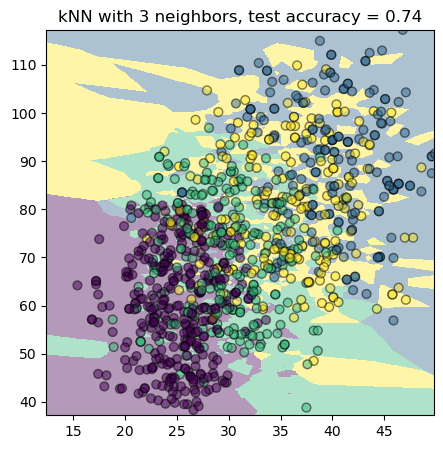

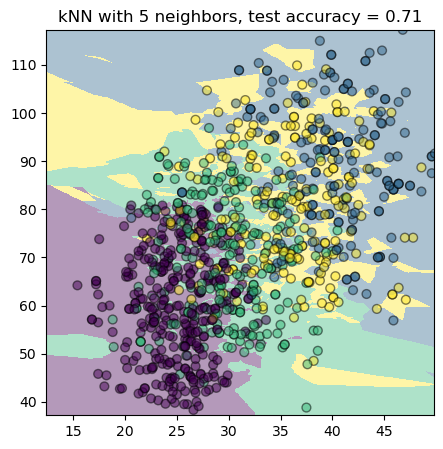

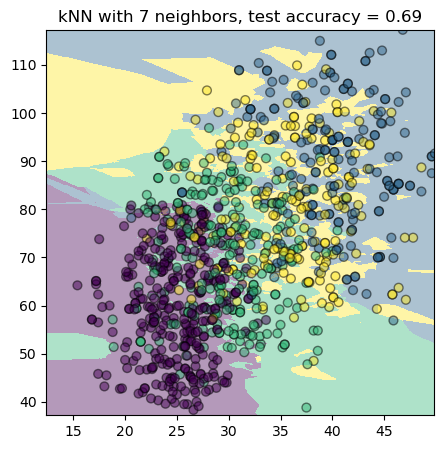

In [10]:
# Function to plot the decision boundary of a classifier
def decision_boundary(X_train, y_train, X_test, y_test, grid_size, model):
    # Determine the boundaries of the feature space
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max()
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max()

    # Create a mesh grid across the feature space
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_size),
        np.arange(y_min, y_max, grid_size)
    )
    
    # Predict on each point in the grid
    pred = model.predict(np.c_[xx.ravel(), yy.ravel()])
    pred = pred.reshape(xx.shape)  # Reshape to match the grid

    # Create the plot
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(1, 1, 1)

    # Display the decision regions with transparency
    ax.pcolormesh(xx, yy, pred, alpha=0.4)

    # Overlay the test data points on the plot
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, alpha=0.5, s=40, edgecolor="k")

    # Calculate and display the accuracy on the test set
    test_acc = model.score(X_test, y_test)
    plt.title(f"kNN with {model.n_neighbors} neighbors, test accuracy = {test_acc:.2f}")

    # Set limits of the plot to match the mesh grid
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    plt.show()

# Function to create and train a KNN model with a specified number of neighbors
def knn_model(X_train, y_train, n_neighbor):
    model = KNeighborsClassifier(n_neighbors=n_neighbor)
    model.fit(X_train, y_train)
    return model

# Use only the first two features from the dataset for 2D visualization
X = df.iloc[:, :2]

# Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_encoded, train_size=0.8, shuffle=True
)

# Print the shape of the datasets
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Loop through selected k-values and visualize their decision boundaries
for n_neighbor in [1, 3, 5, 7]:
    knn = knn_model(X_train, y_train, n_neighbor=n_neighbor)
    decision_boundary(X_train, y_train, X_test, y_test, grid_size=0.1, model=knn)
